In [29]:
# Run once in this environment: pip install -e .
from pathlib import Path
import random

import matplotlib.pyplot as plt
import yaml

from src.notebooks.utils import find_repo_root, load_npy, make_display_image


# IRMAS Mel + CQT Visualisation (Per Class)


In [30]:
REPO_ROOT = find_repo_root()
AUDIO_CFG_PATH = REPO_ROOT / "src/configs/audio_params.yaml"
LABELS_CFG_PATH = REPO_ROOT / "src/configs/labels.yaml"

with open(AUDIO_CFG_PATH, "r", encoding="utf-8") as f:
    audio_cfg = yaml.safe_load(f) or {}

with open(LABELS_CFG_PATH, "r", encoding="utf-8") as f:
    labels_cfg = yaml.safe_load(f) or {}

irmas_cfg = audio_cfg["datasets"]["irmas"]
irmas_labels = [str(x).strip().lower() for x in labels_cfg.get("irmas_labels", [])]
if not irmas_labels:
    raise ValueError(f"No irmas_labels found in {LABELS_CFG_PATH}")

processed_root = (REPO_ROOT / irmas_cfg["cache_root"]).resolve()
MELS_ROOT = processed_root / "log_mels"
CQT_ROOT = processed_root / "log_cqt"

print(f"Repo root: {REPO_ROOT}")
print(f"Processed root (from audio_params): {processed_root}")
print(f"MELS_ROOT: {MELS_ROOT}")
print(f"CQT_ROOT: {CQT_ROOT}")
print(f"IRMAS labels ({len(irmas_labels)}): {', '.join(irmas_labels)}")


Repo root: /Users/hughsignoriello/Developer/ml-based-analysis-of-sound
Processed root (from audio_params): /Users/hughsignoriello/Developer/ml-based-analysis-of-sound/data/processed/irmas
MELS_ROOT: /Users/hughsignoriello/Developer/ml-based-analysis-of-sound/data/processed/irmas/log_mels
CQT_ROOT: /Users/hughsignoriello/Developer/ml-based-analysis-of-sound/data/processed/irmas/log_cqt
IRMAS labels (10): cel, cla, flu, gac, gel, org, sax, tru, vio, voi


In [31]:
def pick_one_feature_file(feature_root: Path, label: str, seed: int = 1337):
    label_dir = feature_root / label
    if not label_dir.exists():
        return None

    files = sorted(label_dir.rglob("*.npy"))
    if not files:
        return None

    rng = random.Random(f"{seed}:{feature_root.name}:{label}")
    return rng.choice(files)


rows = []
for label in irmas_labels:
    mel_path = pick_one_feature_file(MELS_ROOT, label, seed=1337)
    cqt_path = pick_one_feature_file(CQT_ROOT, label, seed=1337)
    rows.append((label, mel_path, cqt_path))

missing_mel = [label for label, mel_path, _ in rows if mel_path is None]
missing_cqt = [label for label, _, cqt_path in rows if cqt_path is None]

print(f"Classes missing mel: {missing_mel if missing_mel else 'none'}")
print(f"Classes missing cqt: {missing_cqt if missing_cqt else 'none'}")


Classes missing mel: none
Classes missing cqt: none


## One Sample Per IRMAS Class (Separate CQT and Mel Grids)


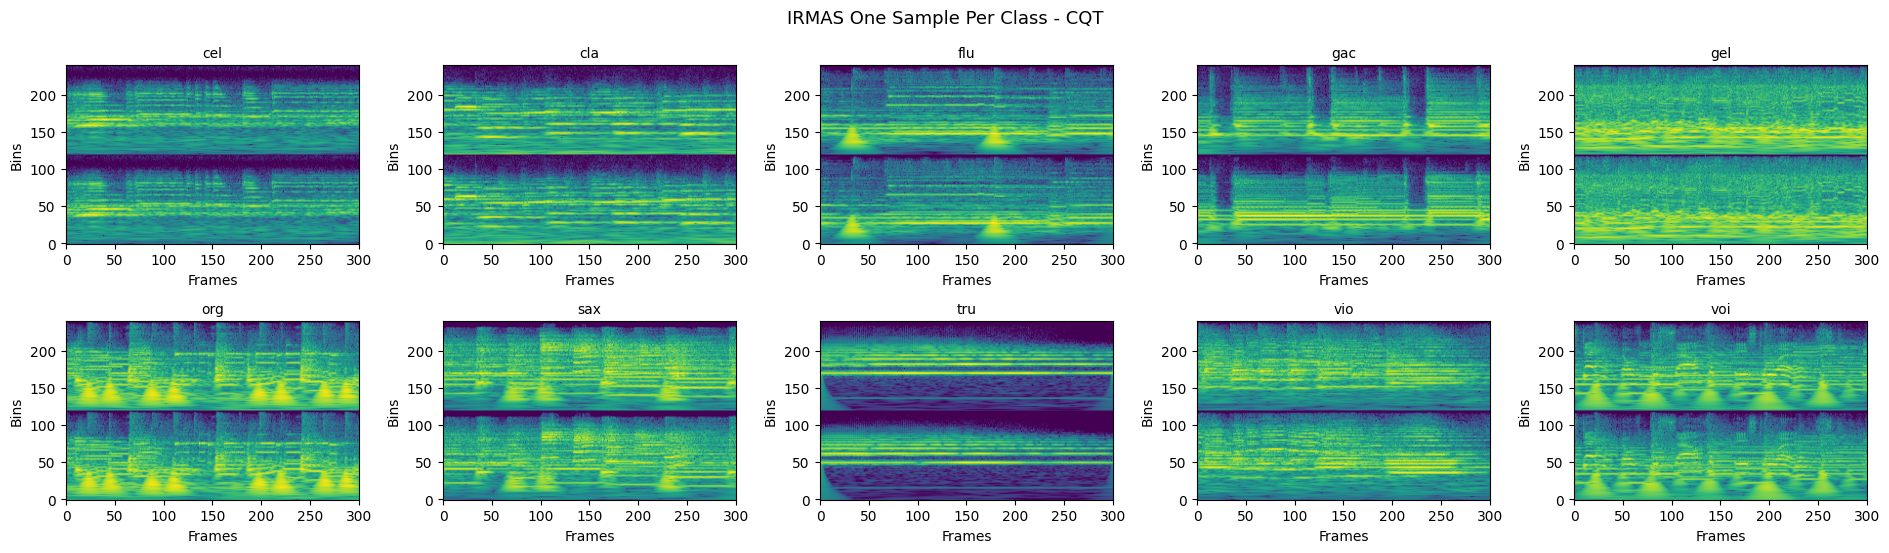

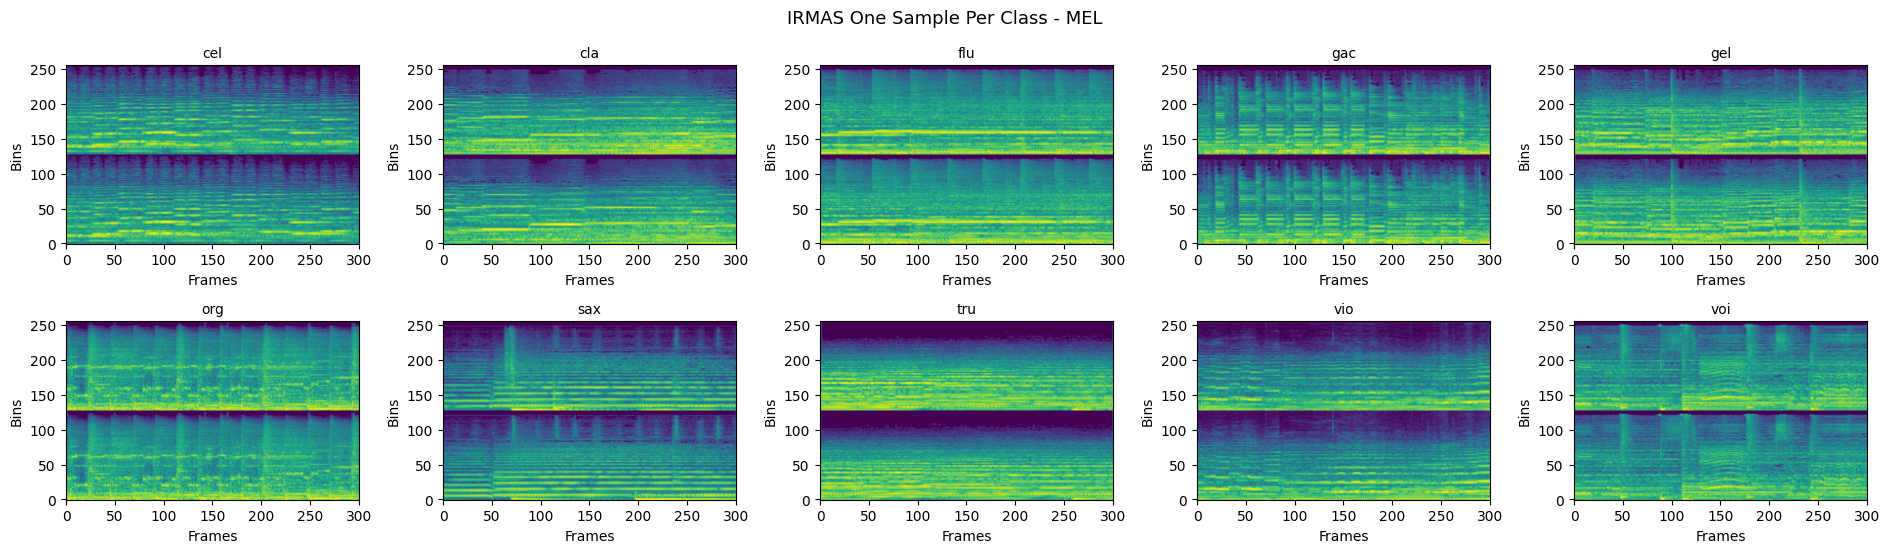

In [32]:
if not rows:
    raise ValueError("No IRMAS class rows prepared.")


def plot_feature_grid(rows, feature_name: str):
    if feature_name.lower() not in {"mel", "cqt"}:
        raise ValueError("feature_name must be 'mel' or 'cqt'")

    idx = 1 if feature_name.lower() == "mel" else 2
    n_items = len(rows)
    cols = min(5, max(1, n_items))
    nrows = (n_items + cols - 1) // cols

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=cols,
        figsize=(3.8 * cols, 2.8 * nrows),
        squeeze=False,
    )

    for k, (label, mel_path, cqt_path) in enumerate(rows):
        r, c = divmod(k, cols)
        ax = axes[r, c]
        feature_path = (mel_path, cqt_path)[idx - 1]

        if feature_path is None:
            ax.axis("off")
            ax.set_title(f"{label} ({feature_name.upper()} missing)", fontsize=9)
            continue

        arr = load_npy(feature_path)
        img = make_display_image(arr, tile="v", db_min=-80.0, db_max=0.0)
        ax.imshow(img, aspect="auto", origin="lower")
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("Frames")
        ax.set_ylabel("Bins")

    for k in range(n_items, nrows * cols):
        r, c = divmod(k, cols)
        axes[r, c].axis("off")

    fig.suptitle(f"IRMAS One Sample Per Class - {feature_name.upper()}", fontsize=13)
    fig.tight_layout()
    plt.show()


# 1) All CQT class samples
plot_feature_grid(rows, "cqt")

# 2) All Mel class samples
plot_feature_grid(rows, "mel")



## Chinese Mel Visualisation Per Class (Manifest-Driven)


In [ ]:
import pandas as pd

CHINESE_MELS_MANIFEST = (REPO_ROOT / "data/processed/chinese_instruments_train_mels.csv").resolve()


def _read_csv_with_fallback(path: Path) -> pd.DataFrame:
    encodings = ("utf-8", "utf-8-sig", "gbk", "cp936")
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)


def _resolve_feature_path(path_like: str) -> Path:
    p = Path(str(path_like))
    if p.is_absolute():
        return p
    return (REPO_ROOT / p).resolve()


if not CHINESE_MELS_MANIFEST.exists():
    raise FileNotFoundError(
        f"Chinese mel manifest not found: {CHINESE_MELS_MANIFEST}. "
        "Generate it first (e.g. make chinese FEATURE=mel)."
    )

ch_mel_df = _read_csv_with_fallback(CHINESE_MELS_MANIFEST)
required_cols = {"filepath", "label"}
if not required_cols.issubset(set(ch_mel_df.columns)):
    raise ValueError(f"Manifest must contain columns {required_cols}; got {set(ch_mel_df.columns)}")

label_series = ch_mel_df["label"].fillna("").astype(str).str.strip().str.lower()
chinese_labels = sorted([x for x in label_series.unique() if x])

chinese_samples = []
for label in chinese_labels:
    sub = ch_mel_df[label_series == label]
    if sub.empty:
        continue
    mel_path = _resolve_feature_path(sub.iloc[0]["filepath"])
    if mel_path.exists():
        chinese_samples.append((label, mel_path))

print(f"Chinese labels in manifest: {len(chinese_labels)}")
print(f"Chinese labels with existing mel files: {len(chinese_samples)}")

if not chinese_samples:
    raise ValueError("No Chinese mel files found to plot.")

n_items = len(chinese_samples)
cols = min(5, max(1, n_items))
nrows = (n_items + cols - 1) // cols
fig, axes = plt.subplots(nrows=nrows, ncols=cols, figsize=(3.8 * cols, 2.8 * nrows), squeeze=False)

for k, (label, mel_path) in enumerate(chinese_samples):
    r, c = divmod(k, cols)
    ax = axes[r, c]
    arr = load_npy(mel_path)
    img = make_display_image(arr, tile="v", db_min=-80.0, db_max=0.0)
    ax.imshow(img, aspect="auto", origin="lower")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Frames")
    ax.set_ylabel("Bins")

for k in range(n_items, nrows * cols):
    r, c = divmod(k, cols)
    axes[r, c].axis("off")

fig.suptitle("Chinese Instruments - One Mel Sample Per Class", fontsize=13)
fig.tight_layout()
plt.show()
